# FASE 2 - Modelo Predictivo: Clasificacion de Riesgo Coronario
## Proyecto Cardiologia Analytics

**Modelo:** Random Forest (interpretable via importancia de variables).

Lee `output/heart_preparado.csv` (Fase 1) y genera:
- `output/heart_enriquecido.csv` -> base del dashboard (Fase 3)
- `output/modelo_rf.joblib` -> modelo entrenado (Fase 4)

**Decision metodologica clave:** para asignar un score honesto a los 918 pacientes
sin fuga de informacion (data leakage), se usa **validacion cruzada out-of-fold**
(`cross_val_predict`): cada paciente recibe su probabilidad desde un modelo que
nunca lo vio en entrenamiento. Ademas se separa un conjunto de prueba (test) para
reportar la matriz de confusion limpia.


### Celda 1 - Librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     cross_val_predict, StratifiedKFold)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
sns.set_theme(style="whitegrid", palette="Set2")
np.random.seed(42)
print("Librerias cargadas")

Librerias cargadas


### Celda 2 - Cargar datos y definir variables
Usamos las 11 variables clinicas. Las categoricas se codifican con OneHot; Random Forest no requiere escalar las numericas.

In [2]:
df = pd.read_csv("../output/heart_preparado.csv")

NUMERICAS   = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
CATEGORICAS = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
TARGET      = "HeartDisease"

X = df[NUMERICAS + CATEGORICAS]
y = df[TARGET]
print("Pacientes:", len(df), "| Variables:", X.shape[1])
print("Prevalencia: {:.1f}%".format(y.mean()*100))

Pacientes: 918 | Variables: 11
Prevalencia: 55.3%


### Celda 3 - Definir el pipeline del modelo
`class_weight='balanced'` hace al modelo mas sensible a la clase enferma (importante en cribado clinico).

In [3]:
def construir_pipeline():
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAS),
        ("num", "passthrough", NUMERICAS),
    ])
    modelo = RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1)
    return Pipeline([("pre", pre), ("rf", modelo)])

pipe = construir_pipeline()
pipe

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'ChestPainType',
                                                   'RestingECG',
                                                   'ExerciseAngina',
                                                   'ST_Slope']),
                                                 ('num', 'passthrough',
                                                  ['Age', 'RestingBP',
                                                   'Cholesterol', 'FastingBS',
                                                   'MaxHR', 'Oldpeak'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=5, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

### Celda 4 - Entrenar y evaluar en conjunto de prueba (20% no visto)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
pipe.fit(X_train, y_train)
y_pred  = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print("Accuracy   : {:.3f}".format(accuracy_score(y_test, y_pred)))
print("Precision  : {:.3f}".format(precision_score(y_test, y_pred)))
print("Recall/Sens: {:.3f}".format(recall_score(y_test, y_pred)))
print("F1-score   : {:.3f}".format(f1_score(y_test, y_pred)))
print("ROC-AUC    : {:.3f}".format(roc_auc_score(y_test, y_proba)))
print()
print(classification_report(y_test, y_pred, target_names=["Sano", "Enfermo"]))

Accuracy   : 0.897
Precision  : 0.903
Recall/Sens: 0.912
F1-score   : 0.907
ROC-AUC    : 0.928

              precision    recall  f1-score   support

        Sano       0.89      0.88      0.88        82
     Enfermo       0.90      0.91      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.90       184
weighted avg       0.90      0.90      0.90       184



### Celda 5 - Matriz de confusion
El error mas costoso clinicamente es el **Falso Negativo**: un enfermo clasificado como sano.

Verdaderos Negativos: 72
Falsos Positivos    : 10
Falsos Negativos    : 9  <- enfermos no detectados
Verdaderos Positivos: 93


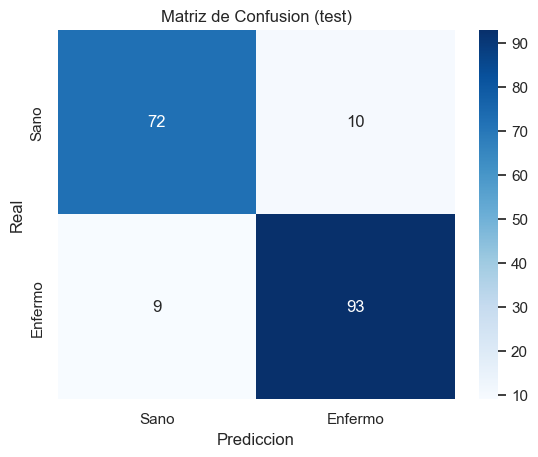

In [5]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Verdaderos Negativos:", tn)
print("Falsos Positivos    :", fp)
print("Falsos Negativos    :", fn, " <- enfermos no detectados")
print("Verdaderos Positivos:", tp)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sano","Enfermo"], yticklabels=["Sano","Enfermo"])
plt.xlabel("Prediccion"); plt.ylabel("Real"); plt.title("Matriz de Confusion (test)")
plt.show()

### Celda 6 - Validacion cruzada 5-fold (robustez)

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_cv = cross_val_score(construir_pipeline(), X, y, cv=cv, scoring="roc_auc")
rec_cv = cross_val_score(construir_pipeline(), X, y, cv=cv, scoring="recall")
print("ROC-AUC: {:.3f} +/- {:.3f}".format(auc_cv.mean(), auc_cv.std()))
print("Recall : {:.3f} +/- {:.3f}".format(rec_cv.mean(), rec_cv.std()))

ROC-AUC: 0.925 +/- 0.026
Recall : 0.886 +/- 0.032


### Celda 7 - Interpretabilidad: importancia de variables

ST_Slope_Up          0.201
ST_Slope_Flat        0.130
ChestPainType_ASY    0.112
Oldpeak              0.088
ExerciseAngina_Y     0.078
ExerciseAngina_N     0.072
MaxHR                0.069
Cholesterol          0.041
Age                  0.040
RestingBP            0.032
dtype: float64


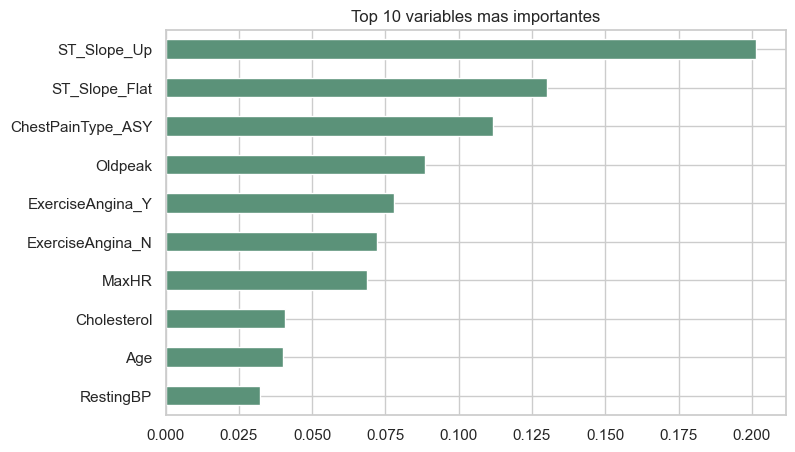

In [7]:
pipe.fit(X, y)  # reajuste sobre todo el dataset (modelo final)
ohe = pipe.named_steps["pre"].named_transformers_["cat"]
nombres = list(ohe.get_feature_names_out(CATEGORICAS)) + NUMERICAS
imp = pd.Series(pipe.named_steps["rf"].feature_importances_, index=nombres).sort_values(ascending=False)
print(imp.head(10).round(3))
imp.head(10).sort_values().plot(kind="barh", color="#5b9279", figsize=(8,5))
plt.title("Top 10 variables mas importantes"); plt.show()

### Celda 8 - Score honesto para los 918 pacientes (out-of-fold)
Cada paciente recibe su probabilidad desde un modelo que no lo vio en entrenamiento.

In [8]:
proba_oof = cross_val_predict(construir_pipeline(), X, y, cv=cv, method="predict_proba")[:, 1]
df["Probabilidad_Riesgo"] = proba_oof.round(4)
df["Prediccion_Final"]    = (proba_oof >= 0.5).astype(int)

print("Probabilidad media:", round(df["Probabilidad_Riesgo"].mean(), 3))
print("Alto Riesgo (Prediccion_Final=1):", int(df["Prediccion_Final"].sum()))
print("Criticos (Probabilidad > 0.80)  :", int((df["Probabilidad_Riesgo"] > 0.80).sum()))
df[["ID_Paciente","HeartDisease","Probabilidad_Riesgo","Prediccion_Final"]].head()

Probabilidad media: 0.536
Alto Riesgo (Prediccion_Final=1): 517
Criticos (Probabilidad > 0.80)  : 326


,ID_Paciente,HeartDisease,Probabilidad_Riesgo,Prediccion_Final
0,PAC-00001,0,0.0170,0
1,PAC-00002,1,0.2633,0
2,PAC-00003,0,0.1053,0
3,PAC-00004,1,0.6687,1
4,PAC-00005,0,0.0552,0


### Celda 9 - Exportar entregables

In [9]:
df.to_csv("../output/heart_enriquecido.csv", index=False)
joblib.dump(pipe, "../output/modelo_rf.joblib")
print("Guardado 'heart_enriquecido.csv' -", df.shape[1], "columnas")
print("Guardado 'modelo_rf.joblib' (modelo final para la Fase 4)")

Guardado 'heart_enriquecido.csv' - 23 columnas
Guardado 'modelo_rf.joblib' (modelo final para la Fase 4)
